# Composer Classification from Symbolic MIDI

This master notebook is the shared, reproducible experiment flow for the AAI-511 project. It builds a clean file-level manifest, runs exploratory analysis, trains the LSTM baseline, and reserves the test set for the final LSTM-versus-CNN comparison.

Reusable implementation lives in `src/`. The runtime prefers Apple Silicon MPS, then CUDA, then CPU. Before running this notebook for the first time, configure Kaggle credentials and run `pixi run prepare-dataset` from the repository root so the raw corpus is available under `dataset/raw/`. MIDI-level EDA is parsed once and cached in `dataset/processed/eda_metadata.csv`; this notebook then presents the cached summary tables and figures.

In [1]:
from pathlib import Path
import sys

import pandas as pd

REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == "notebooks":
    REPO_ROOT = REPO_ROOT.parent
SRC_DIR = REPO_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from experiments import (
    ExperimentConfig,
    prepare_experiment,
    run_cnn_baseline,
    run_lstm_baseline,
)
from project_config import RAW_DATA_DIR
from visualization import plot_cnn_results, plot_exploration, plot_lstm_results

CONFIG = ExperimentConfig(
    max_sequence_length=4096,
    epochs=20,
    learning_rate=1e-3,
    # Set True only after changing EDA metadata features.
    refresh_eda=False,
)

print(f"Repository: {REPO_ROOT}")
print(f"Raw data: {RAW_DATA_DIR / 'midiclassics'}")

Repository: /Users/marston.ward/Developer/personal/AAI-511/final-project/music-composer-classification-pytorch
Raw data: /Users/marston.ward/Developer/personal/AAI-511/final-project/music-composer-classification-pytorch/dataset/raw/midiclassics


/Users/marston.ward/Developer/personal/AAI-511/final-project/music-composer-classification-pytorch/.pixi/envs/default/lib/python3.12/site-packages/pretty_midi/pretty_midi.py:122: RuntimeWarning: Tempo, Key or Time signature change events found on non-zero tracks.  This is not a valid type 0 or type 1 MIDI file.  Tempo, Key or Time Signature may be wrong.
  warnings.warn(


Device: mps
Clean files: 1608
Newly excluded files: 0
Normalization statistics: {'velocity': (79.99657440185547, 23.89927101135254), 'duration': (0.35103198885917664, 0.49335524439811707), 'time_interval': (0.09354662150144577, 0.17110909521579742)}


split,train,validation,test,total
composer,,,,
Bach,709,152,153,1014
Beethoven,146,31,31,208
Chopin,92,20,20,132
Mozart,178,38,38,254


,duration_s,tempo_bpm,note_count,note_density,pitch_range,mean_pitch
composer,,,,,,
Bach,160.26,89.68,1687.37,9.29,43.09,62.33
Beethoven,518.31,123.30,8051.99,14.48,61.07,63.74
Chopin,222.29,111.96,2509.78,11.57,62.98,62.93
Mozart,415.52,104.90,5475.17,13.69,55.31,64.86


(<Figure size 800x400 with 1 Axes>, <Figure size 1300x400 with 2 Axes>)

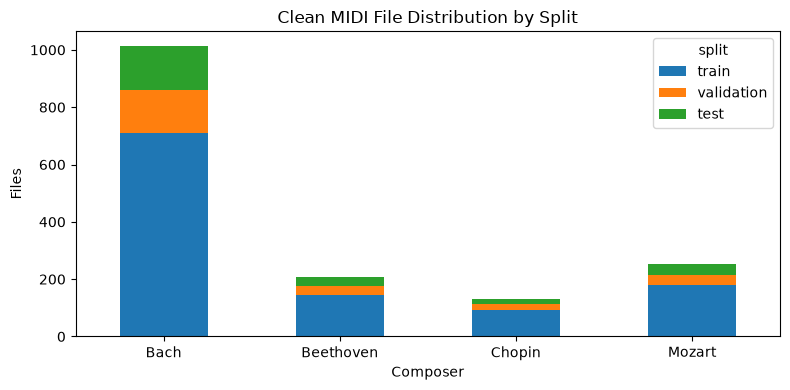

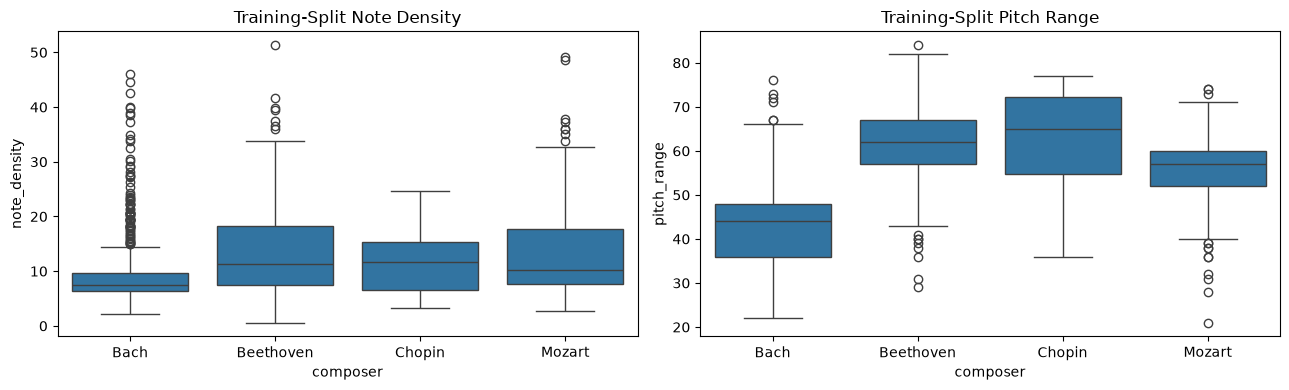

In [2]:
experiment = prepare_experiment(CONFIG)

print(f"Device: {experiment.device}")
print(f"Clean files: {len(experiment.manifest)}")
print(f"Newly excluded files: {len(experiment.exclusions)}")
print(f"Normalization statistics: {experiment.split_features.normalization}")
display(experiment.inventory)
display(experiment.eda_summary)

plot_exploration(experiment.inventory, experiment.train_metadata)

## LSTM Baseline

The baseline is a PyTorch LSTM that combines an embedding of MIDI pitch tokens with velocity, note duration, and time-interval features. Its architecture is defined in `src/models.py`, and the reproducible training workflow, including inverse-frequency class weighting, checkpoint selection by validation performance, and MPS support, is defined in `src/experiments.py`.

The next cell instantiates the model, trains it on the fixed training split, and presents the model structure, class weights, validation report, loss curve, and confusion matrix. The test split remains unused.

Epoch 01/20 | train loss 1.3125 | train accuracy 0.5396 | validation loss 1.0951 | validation accuracy 0.6349


Epoch 02/20 | train loss 1.1400 | train accuracy 0.6391 | validation loss 1.0097 | validation accuracy 0.6017


Epoch 03/20 | train loss 1.0628 | train accuracy 0.6542 | validation loss 0.8556 | validation accuracy 0.6639


Epoch 04/20 | train loss 0.9901 | train accuracy 0.6667 | validation loss 0.8513 | validation accuracy 0.6515


Epoch 05/20 | train loss 0.9442 | train accuracy 0.6978 | validation loss 0.8519 | validation accuracy 0.7054


...

Epoch 09/20 | train loss 0.7508 | train accuracy 0.7431 | validation loss 0.7699 | validation accuracy 0.6929


Epoch 10/20 | train loss 0.6825 | train accuracy 0.7680 | validation loss 0.7273 | validation accuracy 0.7054


Epoch 11/20 | train loss 0.6483 | train accuracy 0.7902 | validation loss 0.7375 | validation accuracy 0.7261
Early stopping at epoch 11: no validation improvement in 5 epochs (best epoch 06).
LSTMComposerClassifier(
  (embedding): Embedding(129, 32, padding_idx=0)
  (lstm): LSTM(35, 64, batch_first=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (classifier): Linear(in_features=64, out_features=4, bias=True)
)
Class weights: [0.397 1.926 3.057 1.58 ]
Best validation accuracy: 0.743


,precision,recall,f1-score,support
0,0.866,0.895,0.880,152.000
1,0.476,0.323,0.385,31.000
2,0.750,0.600,0.667,20.000
3,0.447,0.553,0.494,38.000
accuracy,0.743,0.743,0.743,0.743
macro avg,0.635,0.592,0.606,241.000
weighted avg,0.740,0.743,0.738,241.000


(<Figure size 900x400 with 1 Axes>, <Figure size 700x600 with 1 Axes>)

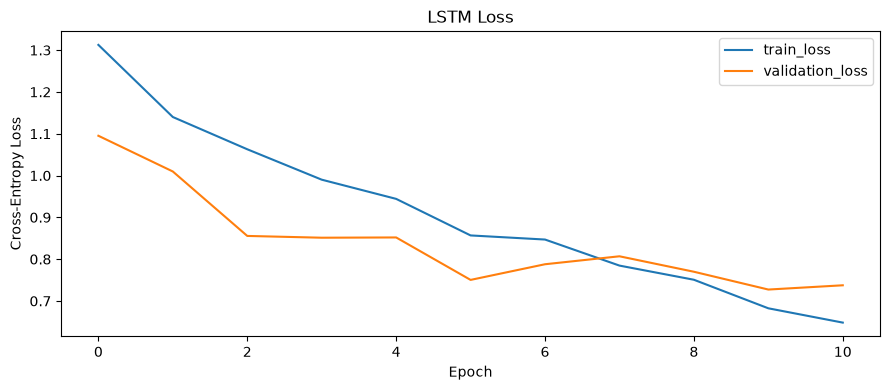

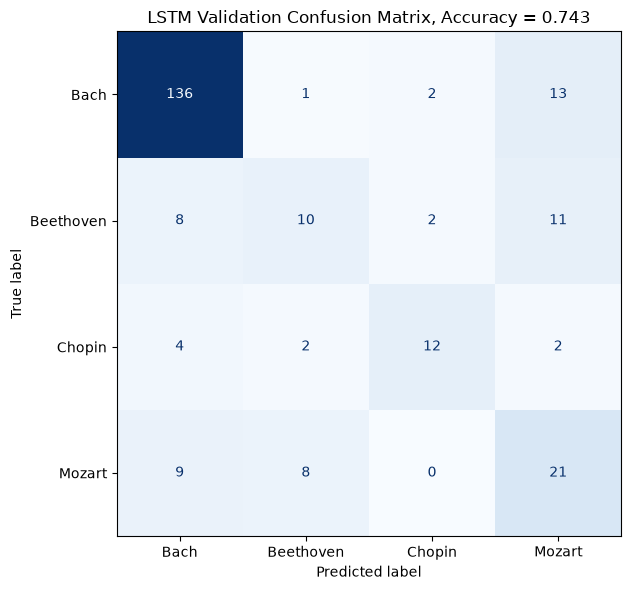

In [3]:
baseline = run_lstm_baseline(experiment, CONFIG)

print(baseline.model)
print(f"Class weights: {baseline.class_weights.numpy().round(3)}")
print(f"Best validation accuracy: {baseline.validation.accuracy:.3f}")
display(pd.DataFrame(baseline.validation.report).transpose().round(3))

plot_lstm_results(baseline.history, baseline.validation)

## CNN Baseline

The CNN uses the same pitch embedding, normalized velocity, duration, and onset-interval features as the LSTM, but learns local musical patterns with three one-dimensional convolutional blocks. Two max-pooling stages reduce the sequence before adaptive global max pooling produces a piece-level representation.

The CNN is trained from the same fixed manifest and class-weighted loss as the LSTM. It is selected by validation performance, and the test split remains sealed until both final architectures have been selected.

Epoch 01/20 | train loss 1.3777 | train accuracy 0.4747 | validation loss 0.8549 | validation accuracy 0.6515


Epoch 02/20 | train loss 1.0952 | train accuracy 0.6000 | validation loss 0.8830 | validation accuracy 0.6266


Epoch 03/20 | train loss 0.9805 | train accuracy 0.6427 | validation loss 0.7752 | validation accuracy 0.7137


Epoch 04/20 | train loss 0.8050 | train accuracy 0.6916 | validation loss 0.7326 | validation accuracy 0.7427


Epoch 05/20 | train loss 0.7627 | train accuracy 0.7191 | validation loss 0.6866 | validation accuracy 0.7718


...

Epoch 12/20 | train loss 0.2873 | train accuracy 0.8978 | validation loss 0.9038 | validation accuracy 0.7178


Epoch 13/20 | train loss 0.2606 | train accuracy 0.9271 | validation loss 1.4823 | validation accuracy 0.7137


Epoch 14/20 | train loss 0.2661 | train accuracy 0.9289 | validation loss 0.8403 | validation accuracy 0.7676
Early stopping at epoch 14: no validation improvement in 5 epochs (best epoch 09).
CNNComposerClassifier(
  (embedding): Embedding(129, 32, padding_idx=0)
  (conv_block_1): Sequential(
    (0): Conv1d(35, 64, kernel_size=(5,), stride=(1,), padding=(2,))
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool1d(kernel_size=4, stride=4, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv1d(64, 128, kernel_size=(5,), stride=(1,), padding=(2,))
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool1d(kernel_size=4, stride=4, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_3): Sequential(
    (0): Conv1d(128, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): BatchNorm1d(128, 

,precision,recall,f1-score,support
0,0.910,0.934,0.922,152.000
1,0.618,0.677,0.646,31.000
2,0.842,0.800,0.821,20.000
3,0.625,0.526,0.571,38.000
accuracy,0.826,0.826,0.826,0.826
macro avg,0.749,0.734,0.740,241.000
weighted avg,0.822,0.826,0.823,241.000


(<Figure size 900x400 with 1 Axes>, <Figure size 700x600 with 1 Axes>)

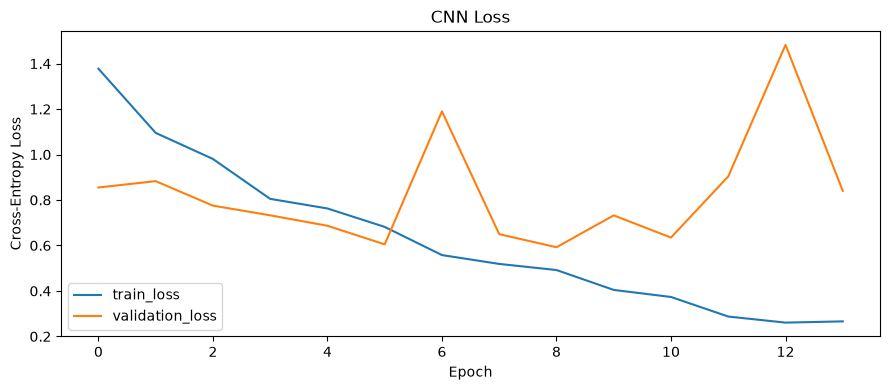

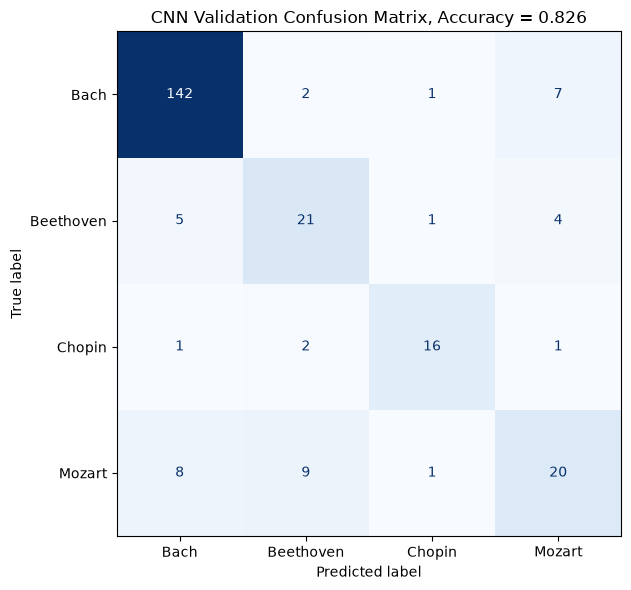

In [4]:
cnn_baseline = run_cnn_baseline(experiment, CONFIG)

print(cnn_baseline.model)
print(f"Class weights: {cnn_baseline.class_weights.numpy().round(3)}")
print(f"Best validation accuracy: {cnn_baseline.validation.accuracy:.3f}")
display(pd.DataFrame(cnn_baseline.validation.report).transpose().round(3))

plot_cnn_results(cnn_baseline.history, cnn_baseline.validation)